# DATA Practical 9 -  Linear Regression - Model Answers



## "...all models are wrong, but some are useful. However, the approximate nature of the model must always be borne in mind...." (George Box) [Wikipedia](https://en.wikipedia.org/wiki/All_models_are_wrong)

**Pandas API Reference**: https://pandas.pydata.org/pandas-docs/stable/reference/index.html

**Matplotlib API Reference**: https://matplotlib.org/stable/api/index.html

**Seaborn API Reference**: https://seaborn.pydata.org/api.html

**Scipy Stats API Reference**: https://docs.scipy.org/doc/scipy/reference/stats.html

**Linear regrression on Scikit Learn**: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math as m
import pandas as pd

#Check this:  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
from sklearn import linear_model 


***

## **Linear Regression Example (from Lecture)**

### Input Data

In [2]:
#House prices
price = [275000.0, 282500.0, 305000.0, 340000.0, 362500.0]
area  = [2600, 3000, 3200, 3600, 4000]

#Create a dataframe
dfHouse = pd.DataFrame(data={"Area":area, "Price":price})

### Create the linear regression object

In [3]:
lrModel = linear_model.LinearRegression()

### Transform the data in the appropriate format

In [4]:
#Reshape the independent variable - pay attention to how the data are expected by the linear regression model 
#(2D -> multiple indepedent variables)
trainX = np.array(dfHouse['Area']).reshape(-1, 1)

### Train the model

In [6]:
#Train the model
lrModel.fit(X=trainX, y=dfHouse['Price'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Make predictions

In [7]:
#Predict the price for a property with area 3300
area = 3300

#Note: similarly to the fit function, predict expects multiple independent variables
result = lrModel.predict([[area]])

print("The price of a property of %d square feet is £%.2f" % (area, result[0]))


The price of a property of 3300 square feet is £314357.88


### Make predictions for a range of values

In [8]:
minArea = dfHouse['Area'].min()-1
maxArea = dfHouse['Area'].max()+1
predictPrice = lrModel.predict(np.arange(minArea,maxArea).reshape(-1, 1))

predictPrice

array([266764.29794521, 266832.19178082, 266900.08561644, ...,
       361747.7739726 , 361815.66780822, 361883.56164384], shape=(1402,))

### Plot result

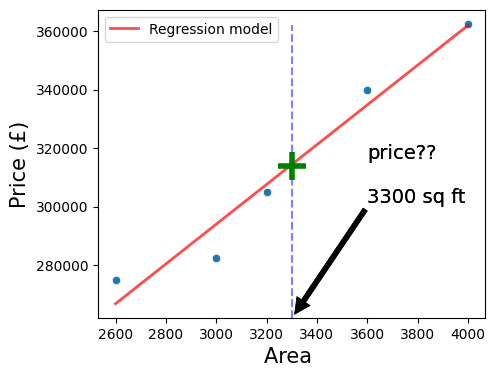

In [9]:
plt.figure(figsize=(5,4), dpi=100)
ax = sns.scatterplot(x="Area", y="Price", data=dfHouse, marker='o')
ax.set_xlabel('Area ',fontsize=15) # set x label
ax.set_ylabel('Price (£)',fontsize=15,rotation=90) # set y label

#produce the plot
ax = sns.lineplot(y=predictPrice, x=np.arange(minArea,maxArea), linestyle='-', color="r", label="Regression model", alpha=0.7, lw=2)



#add annotations
ax.annotate("price??\n\n3300 sq ft ", xy=(3310, 263000), xytext=(3600, 300000), size=14,  va="bottom", ha="left",
            arrowprops=dict(facecolor='black', lw=3.5, ls='--', ec='None'))

ax.axvline(x=3300, ymax=0.95, color='b',alpha=0.5, ls='--') # vertical line


ax.annotate("price??\n\n3300 sq ft ", xy=(3310, 263000), xytext=(3600, 300000), size=14,  va="bottom", ha="left",
            arrowprops=dict(facecolor='black', lw=3.5, ls='--', ec='None'))

ax.plot(3300, 314000, '+', ms=10 * 2, mec='g', mfc='none', mew=4)

plt.show()


***
***
## **Linear Regression Part A**

DataVision has been commissioned by the York City Council to analyse a set of data regarding citizens of Yorkshire and extract actionable knowledge.

**TA1) Load the Yorkshire dataset using Pandas**

**Note**: You have to download the dataset on your local machine and then load it onto your Jupyter Notebook.

In [10]:
dfYork = pd.read_csv("yorkshireP9.csv")
dfYork.head()

,id,age,gender,region,income,married,children,car,mortgage
0,ID12101,48,FEMALE,INNER_CITY,17546.000000,NO,1,NO,NO
1,ID12102,40,MALE,TOWN,30085.100000,YES,3,YES,YES
2,ID12103,51,FEMALE,INNER_CITY,16575.400000,YES,0,YES,NO
3,ID12104,23,FEMALE,TOWN,20375.400000,YES,3,NO,NO
4,ID12105,57,FEMALE,RURAL,15944.690366,YES,0,NO,NO


**TA2) Produce a scatter plot showing the age VS income.**

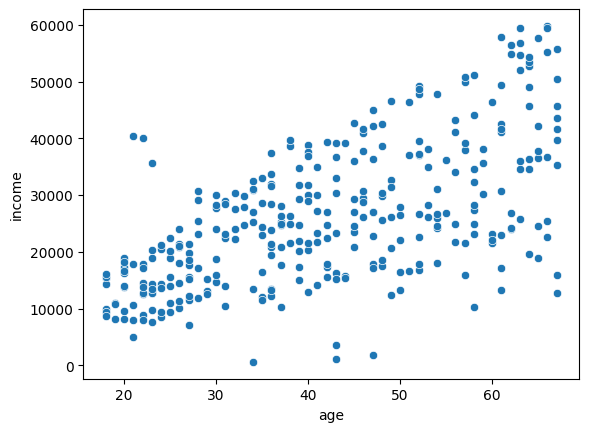

In [14]:
#Write your answer here
ax = sns.scatterplot(x="age", y="income", data=dfYork)
ax.set_xlabel("Age")
ax.set_ylabel("Income")


**TA3) Train a linear regression model to determine the "best line of fit" for this data using only the age as the independent variable to predict the income.**

* **Hint**: 
   * You might want to use the following library: from sklearn import linear_model
   * You might want to check https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
   * Pay attention to how the data should be shaped (see the example above)

In [11]:
#Write your answer here


**TA4) Extract and report the coefficients (regression and intercept coefficient) of the trained linear regression model.**

* **Hint**: 
   * You might want to check the attributes of the linear regression model at 
   https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [12]:
#Write your answer here


**TA5) Calculate the regression and intercept coefficients using their mathematical definitions (formulae) and confirm that they match the result derived in task TA4.**

In [13]:
#Write your answer here


**TA6) Using your age, make a prediction about your income in 10 years time (i.e., your age in 2033). Also, report the complete linear regression model.**


In [14]:
#Write your answer here


**TA7) Plot the linear regression model alongside the scatter plot from TA2.**

**Hint:** 
  * Invoke the plotting functions (one for the scatter plot, one for the linear regression model) one after the other
  * To generate the linear regression model, you can use (i) high school maths or (ii) the predict() method of the LinearRegression library



In [15]:
#Write your answer here


*** 

## **Linear Regression Part B**

A dietetics and nutrition instructor wants to analyse how well educated sports science students are about the usefuleness of calcium and its recommended daily intake. Also, the instructor wants to examine if knowledge about calcium can be used to predict calcium intake of the students. To answer these questions, the instructor collected data from 20 students about their calcium knowledge and calcium intake per day.


**TB1) Load the Nutrition dataset using Pandas.**

**Note**: You have to download the dataset on your local machine and then load it onto your Jupyter Notebook

In [16]:
dfNut = pd.read_csv("nutritionP9.csv")
dfNut.head()

,KnowledgeScore,CalciumIntake
0,10,450
1,42,1050
2,38,900
3,15,525
4,22,710


**TB2) Which is the independent and which is the dependent variable?**

In [17]:
#Write your answer here


**TB3) Plot a scatter plot having the independent variable on the X axis. Do you see any relationship between the variables?**

In [18]:
#Write your answer here


**TB4) Calculate the Pearson correlation coefficient. You must show your calculations, i.e., calculate the result analytically, but you may use the appropriate scipy.stats function (or other) to check your result.**

In [19]:
#Write your answer here


**TB5) What do you think of the correlation between these two variables? What do you expect the linear regression model to be?**

In [20]:
#Write your answer here


**TB6) Split the dataset into training and testing datasets using the last 20% of data items for testing**

In [21]:
#Write your answer here


**TB7) Train a simple linear regression model to determine the "best line of fit" for this data.**

In [22]:
#Write your answer here


**TB8) Report the regression and intercept coefficients of this linear regression model. Report also the final formula of the linear regression model.**

In [23]:
#Write your answer here


**TB9) Calculate the regression and intercept coefficients using their formulae and confirm that they match the result derived in task TB7.**

In [24]:
#Write your answer here


**TB10) Make predictions for the testing set and print the predicted values**

In [25]:
#Write your answer here


**TB11) Calculate the goodness of fit $R^2$. You must show your calculations, i.e., calculate the result analytically, but you may use the appropriate sklearn.metrics method to check your result.**

**Hint:** 
   * You might want to check https://scikit-learn.org/stable/modules/classes.html#regression-metrics
   * To derive the $R^2$ score you need to make predictions (see lecture slides for the formulae). You may use the same dataset (used for training) for making predictions.

In [26]:
#Write your answer here


**TB12) Plot the linear regression model alongside the scatter plot from task TB3.**

In [27]:
#Write your answer here


**TB13) Calculate the approximate calcium intake of a student with knowledge of calcium score equal to 30 (out of 50).**

In [28]:
#Write your answer here


*** 

## Linear Regression Part C

DataVision is carrying out a survey on behalf of the NHS to assess social factors influencing heart disease. The company has collected data from 500 neighbourhoods in major cities around the country. The data measure the percentage of people per neighbourhood who bike to work, the percentage of people who smoke and the percentage of people who have shown symptoms of heart disease or have heart disease.

**TC1) Load the heartData dataset using Pandas.**

**Note**: You have to download the dataset on your local machine and then load it onto your Jupyter Notebook

In [29]:
#Read the dataset
dfHeart = pd.read_csv("heartDataP9.csv")
dfHeart.head()

,biking,smoking,heartDisease
0,30.801246,10.896608,11.769423
1,65.129215,2.219563,2.854081
2,1.959665,17.588331,17.177803
3,44.800196,2.802559,6.816647
4,69.428454,15.974505,4.062224


**TC2) Partition the independent from the dependent variables (e.g., use one dataframe to hold the independent variables and another for the dependent variable).**

In [30]:
#Write your answer here


**TC3) Split the data into training and testing sets using 80% for training and 20% for testing.**

**Hint:**

* Do you need to split the dataframe holding the independent variables, the dependent variable or both?

In [31]:
#Write your answer here


**TC4) Train the linear regression model using the training set and print the regression and intercept coefficients.**

In [32]:
#Write your answer here


**TC5) Predict the percentage of people that have heart disease for the 20% of data within the testing set**

In [33]:
#Write your answer here


**TC6) Create a dataframe named dfResults to store the actual and predicted percentage of people with heart disease (i.e., use one column for the actual percentage and another second column the predicted percentage of people with heart disease).**

In [34]:
#Write your answer here


#### TC7) Calculate $R^2$, Mean Absolute Error, Mean Squared Error and Root Mean Squared Error. You must show your calculations, i.e., calculate the result analytically, but you may use the appropriate sklearn.metrics method to check your result.


* Hint: You might want to check https://scikit-learn.org/stable/modules/classes.html#regression-metrics

In [35]:
#Write your answer here


### (Bonus) Train a simple linear regression model for each of the independent variables and calculate the $R^2$, Mean Absolute Error, Mean Squared Error and Root Mean Squared Error for each derived regression model. Which performs the best?

In [36]:
#Write your answer here
